# CASM voltage dumps: quickstart tutorial

kernel = the offline venv
(`/home/casm/software/dev/casm_venvs/casm_offline_env`).

Voltages are 4+4-bit complex, one byte per sample: 3072 channels over
390.6-484.4 MHz in six 512-channel streams, stream 0 at the top of the band.
Streams 0-2 are written on casm-corr1, streams 3-5 on casm-corr2. Native
sampling is 32.768 us; one second of the full array is ~12.4 GB on disk.

## 1. Dump and gather

`dump_voltages` triggers the daemons on both nodes, waits for the files,
pulls the corr2 streams into your directory (corr1 ones are symlinked), and
returns what `VoltageReader` needs. The ring buffer holds ~26 s of the past,
so `past_duration=` is capped there; an explicit UTC window can also be passed. Check the plan and disk space first with `dry_run=True`.



In [14]:
# stream 0: 468.750-484.375 MHz (corr1)    stream 3: 421.875-437.500 MHz (corr2)
# stream 1: 453.125-468.750 MHz (corr1)    stream 4: 406.250-421.875 MHz (corr2)
# stream 2: 437.500-453.125 MHz (corr1)    stream 5: 390.625-406.250 MHz (corr2)

In [15]:
from casm_t2.dump_client import dump_voltages

out_dir = "/home/casm/software/vishnu/VOLTAGE_TESTS"
past_duration = 2
utc_start = "2026-07-30-22:25:22.958"
utc_stop = "2026-07-30-22:25:24.958"

subband_streams = [1, 2] 

dump_voltages(out_dir, past_duration=past_duration, dry_run=True)   

window   2026-07-31-01:40:15.383 .. 2026-07-31-01:40:17.383 (2.000 s)
casm-corr1  3 stream(s), writes 12.4 GB, needs 12.4 GB free, has 1080 GB
casm-corr2  3 stream(s), writes 12.4 GB, needs 12.4 GB free, has 6701 GB
dry run: nothing sent


('/home/casm/software/vishnu/VOLTAGE_TESTS', None)

In [16]:
data_dir, prefix = dump_voltages(out_dir, past_duration=past_duration)

# other forms:
# data_dir, prefix = dump_voltages(out_dir, next_duration=10)
# data_dir, prefix = dump_voltages(out_dir, start=utc_start, stop=utc_stop)
# data_dir, prefix = dump_voltages(out_dir, past_duration=past_duration, streams=subband_streams)

data_dir, prefix

window   2026-07-31-01:40:18.411 .. 2026-07-31-01:40:20.411 (2.000 s)
casm-corr1  3 stream(s), writes 12.4 GB, needs 12.4 GB free, has 1080 GB
casm-corr2  3 stream(s), writes 12.4 GB, needs 12.4 GB free, has 6701 GB
stream 0  casm-corr1:27000 -> OK
stream 1  casm-corr1:27001 -> OK
stream 2  casm-corr1:27002 -> OK
stream 3  casm-corr2:27003 -> OK
stream 4  casm-corr2:27004 -> OK
stream 5  casm-corr2:27005 -> OK
gather   waiting on stream(s) 4, 5
gather   stream 0: 1 symlink(s) to local files
gather   stream 1: 1 symlink(s) to local files
gather   stream 2: 1 symlink(s) to local files
gather   stream 3: 1 file(s) from casm-corr2
gather   stream 4: 1 file(s) from casm-corr2
gather   stream 5: 1 file(s) from casm-corr2
gather   WARNING: stream(s) 0, 1, 2 are symlinks into /mnt/nvme4/data/casm/cand_dumps — deleting the originals breaks them; copy them over if /home/casm/software/vishnu/VOLTAGE_TESTS has to stand on its own

gathered under /home/casm/software/vishnu/VOLTAGE_TESTS/stream_N/ —

('/home/casm/software/vishnu/VOLTAGE_TESTS',
 '2026-07-29-21:06:34_0212075347562496')

## 2. Read

 Default return is the raw SNAP layout,
`{snap: (n_time, n_chan, 12)}` complex64 with values -8..7; pass
`antenna_csv=` for one `(n_time, n_chan, n_ant)` array in CSV row order.

In [18]:
from casm_io.voltage import VoltageReader

reader = VoltageReader(data_dir, prefix)
print("streams on disk:", reader.subbands_found)
#read only subbands 1,2
res = reader.read_full_band(subbands=[1, 2], snaps=[0, 3],
                            verbose=True)
v0 = res.voltages[0]
print(f"SNAP 0: {v0.shape} {v0.dtype}   (time, channel, adc)")
print(f"freq: {res.freq_mhz[0]:.4f} -> {res.freq_mhz[-1]:.4f} MHz")

streams on disk: [0, 1, 2, 3, 4, 5]
  Reading subbands [===============>              ] 1/2 Reading /home/casm/software/vishnu/VOLTAGE_TESTS/stream_1/2026-07-29-21:06:34_0212075347562496.000000.dada
  n_time=61036 / 61036 (offset 0), SNAPs=[0, 3]
  Stream 1: n_time=61036 / 61036 (offset 0) from 1 file(s)
  Reading subbands [==============================] 2/2 
Reading /home/casm/software/vishnu/VOLTAGE_TESTS/stream_2/2026-07-29-21:06:34_0212075347562496.000000.dada
  n_time=61036 / 61036 (offset 0), SNAPs=[0, 3]
  Stream 2: n_time=61036 / 61036 (offset 0) from 1 file(s)

SNAP 0 stitched: shape=(61036, 1024, 12), mean_power=0.010

SNAP 3 stitched: shape=(61036, 1024, 12), mean_power=0.359

Frequency axis: 468.750 – 437.531 MHz (1024 channels, descending)
UTC_START: 2026-07-29-21:06:34
SNAP 0: (61036, 1024, 12) complex64   (time, channel, adc)
freq: 468.7500 -> 437.5305 MHz


## 3. Autocorrelation spectra

Accumulate mean |v|^2 per SNAP and ADC — one read covers this dump. Only
when a dump is too long to unpack in memory at once, swap the read for
`reader.iter_full_band(seconds=..., snaps=...)`, which yields the same
data in RAM-sized chunks.

In [19]:
import numpy as np
#read only snaps 0,3
res2 = reader.read_full_band(snaps=[0, 3], verbose=True)
spec = {s: np.sum(v.real**2 + v.imag**2, axis=0)
        for s, v in res2.voltages.items()}
n = res2.voltages[0].shape[0]     
freq = res2.freq_mhz
header = res2.header
print(f"accumulated {n} samples ({n * 32.768e-6:.2f} s) for SNAPs {sorted(spec)}")

  Reading subbands [=====>                        ] 1/6 Reading /home/casm/software/vishnu/VOLTAGE_TESTS/stream_0/2026-07-29-21:06:34_0212075347562496.000000.dada
  n_time=61036 / 61036 (offset 0), SNAPs=[0, 3]
  Stream 0: n_time=61036 / 61036 (offset 0) from 1 file(s)
  Reading subbands [==========>                   ] 2/6 Reading /home/casm/software/vishnu/VOLTAGE_TESTS/stream_1/2026-07-29-21:06:34_0212075347562496.000000.dada
  n_time=61036 / 61036 (offset 0), SNAPs=[0, 3]
  Stream 1: n_time=61036 / 61036 (offset 0) from 1 file(s)
  Reading subbands [===============>              ] 3/6 Reading /home/casm/software/vishnu/VOLTAGE_TESTS/stream_2/2026-07-29-21:06:34_0212075347562496.000000.dada
  n_time=61036 / 61036 (offset 0), SNAPs=[0, 3]
  Stream 2: n_time=61036 / 61036 (offset 0) from 1 file(s)
  Reading subbands [====================>         ] 4/6 Reading /home/casm/software/vishnu/VOLTAGE_TESTS/stream_3/2026-07-29-21:06:34_0212075347562496.000000.dada
  n_time=61036 / 61036 (off

## 4. Visibilities 

`correlate` voltages. `tint_s=None`
keeps the native 32.768 us resolution; anything else rounds to whole
samples. A snap dict is stacked in (snap, adc) order — the labels are in
`.inputs`.

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
from casm_io.voltage import correlate

small = reader.read_full_band(seconds=0.005, subbands=[1], snaps=[0, 3],
                              verbose=True)

native = correlate(small.voltages)              # native resolution
avg = correlate(small.voltages, tint_s=0.001)   # 1 ms integrations

print("native:", native.vis.shape, "(bin, channel, input, input)")
print("1 ms:  ", avg.vis.shape, f"tint = {avg.tint_samples} samples")
print("input 0 is (snap, adc) =", avg.inputs[0])

  Reading subbands [==============================] 1/1 
Reading /home/casm/software/vishnu/VOLTAGE_TESTS/stream_1/2026-07-29-21:06:34_0212075347562496.000000.dada
  n_time=153 / 61036 (offset 0), SNAPs=[0, 3]
  Stream 1: n_time=153 / 61036 (offset 0) from 1 file(s)

SNAP 0 stitched: shape=(153, 512, 12), mean_power=0.011

SNAP 3 stitched: shape=(153, 512, 12), mean_power=0.337

Frequency axis: 468.750 – 453.156 MHz (512 channels, descending)
UTC_START: 2026-07-29-21:06:34
native: (153, 512, 24, 24) (bin, channel, input, input)
1 ms:   (4, 512, 24, 24) tint = 31 samples
input 0 is (snap, adc) = (0, 0)


## 5. Autocorrelation bandpasses

One figure per SNAP, every ADC labelled, local time range in the title.

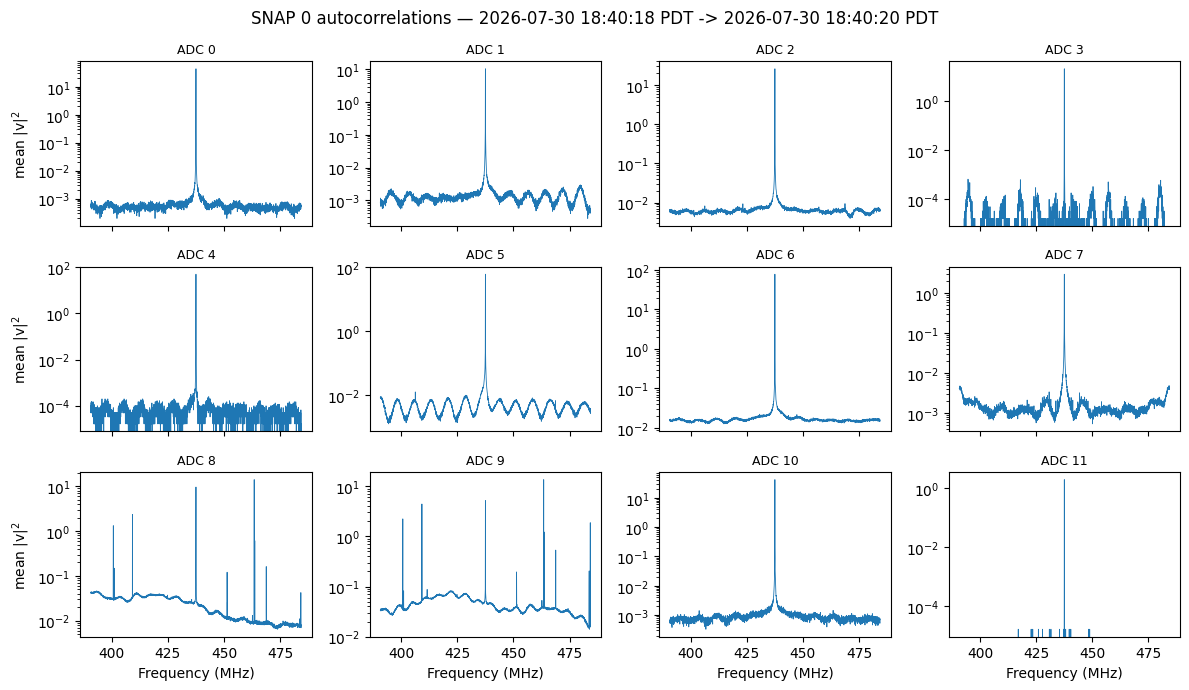

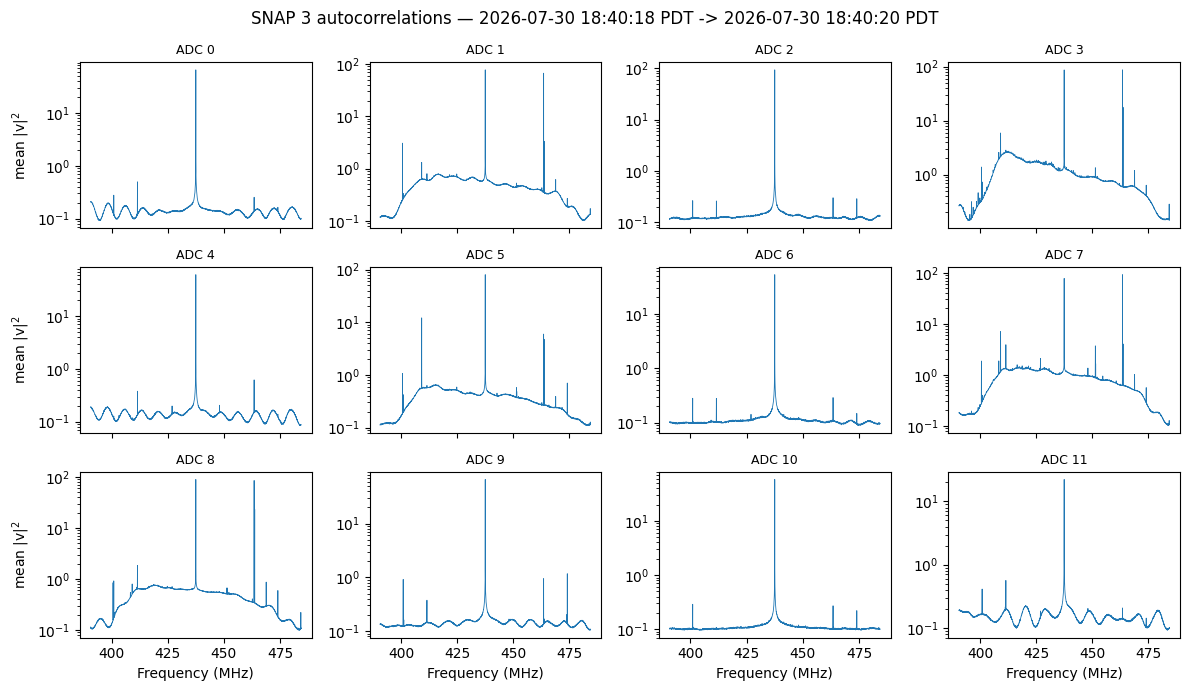

In [21]:
%matplotlib inline
import matplotlib.pyplot as plt
from casm_io.autocorr import psrdada_to_unix
from casm_io._time import format_time_span

t0 = psrdada_to_unix(header.get("DUMP_UTC_START", header["UTC_START"]))
when = format_time_span(t0, t0 + n * 32.768e-6, "America/Los_Angeles")

for snap in sorted(spec):
    fig, axes = plt.subplots(3, 4, figsize=(12, 7), sharex=True)
    for adc in range(spec[snap].shape[1]):
        ax = axes.flat[adc]
        ax.semilogy(freq, spec[snap][:, adc] / n, lw=0.6)
        ax.set_title(f"ADC {adc}", fontsize=9)
    for ax in axes[-1]:
        ax.set_xlabel("Frequency (MHz)")
    for ax in axes[:, 0]:
        ax.set_ylabel("mean |v|$^2$")
    fig.suptitle(f"SNAP {snap} autocorrelations — {when}")
    fig.tight_layout()

## 6. Cleaning up

Nothing deletes dumps automatically (the T3 janitor is off). The cell below
throws away the dump this notebook made — the gathered files in your
directory and the originals in cand_dumps on both nodes. Anything else you
keep is yours to manage. The same flow scripted: `examples/voltage_dumps.py`;
comparison against the correlator: `casm-autocorr`.

In [9]:
cleanup = False   # set True and run to delete the dump this notebook made

if cleanup:
    import glob, os, subprocess
    local = (glob.glob(f"{data_dir}/stream_*/{prefix}*.dada")
             + glob.glob(f"/mnt/nvme4/data/casm/cand_dumps/stream_*/{prefix}*.dada"))
    for f in local:
        os.remove(f)
        print("removed", f)
    subprocess.run(["ssh", "-o", "BatchMode=yes", "casm-corr2",
                    f"rm -v /mnt/nvme4/data/casm/cand_dumps/stream_*/{prefix}*.dada"])